In [1]:
%matplotlib widget

import os
import numpy as np
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
import pytesseract
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, Polygon
import image_utils
from get_cards_playing import card_peek_width, card_width, get_cards, card_height

In [2]:
img_path = "frames/7cards_dealer.png"
img_np = image_utils.load_rdb(img_path)

print(f"Loaded {img_path}")
print(f"shape: {img_np.shape}, dtype: {img_np.dtype}")

Loaded frames/7cards_dealer.png
shape: (1080, 2280, 3), dtype: uint8


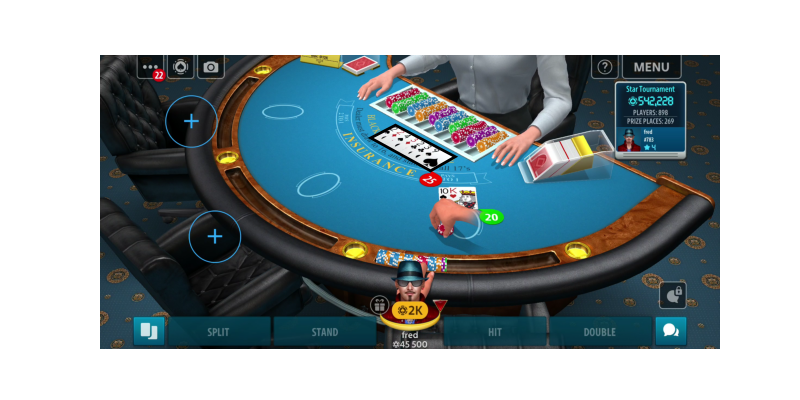

In [3]:
f, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.imshow(img_np)
ax.set_axis_off()

poly_pts = np.array([
    [1086, 257],
    [995, 304],
    [1215, 425],
    [1306, 373],
], dtype=np.float32)

poly = Polygon(
    poly_pts, closed=True, fill=False, ec="black", lw=2
)
ax.add_patch(poly)

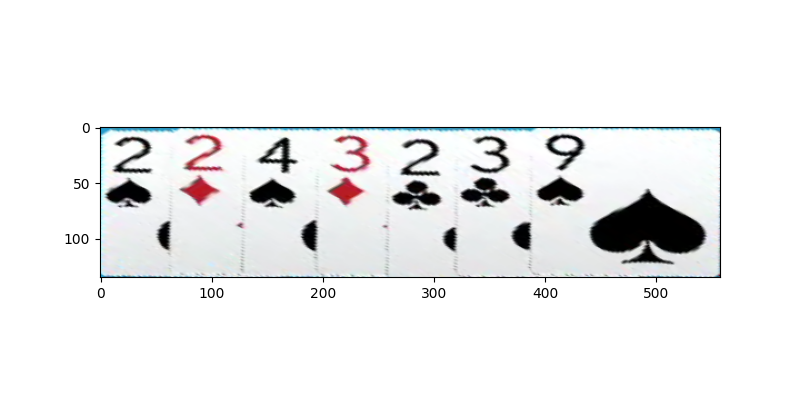

In [4]:
cards = image_utils.wrap_perspective(img_np, poly_pts, card_width + card_peek_width * 6, 135)

f, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.imshow(cards)

In [5]:
cards.shape

(135, 558, 3)

In [6]:
len_wrapped_7 = 6 * card_peek_width + card_width

In [7]:
# dealer max 11 cards (10 peek + 1)
len_wrapped_11 = 10 * card_peek_width + card_width

In [8]:
k = len_wrapped_11 / len_wrapped_7

In [9]:
# Extend edges AD and BC by factor k along directions A->D and B->C (anchored at A and B)
# A, B, C, D correspond to the original quad in poly_pts
A, B, C, D = poly_pts.astype(np.float32)

# Keep A and B fixed; move D and C outwards along their respective directions
D1 = A + (D - A) * k  # extend AD from A toward D
C1 = B + (C - B) * k  # extend BC from B toward C

A1 = A
B1 = B

poly_pts_11 = (np.stack([A1, B1, C1, D1]) + 0.5).astype(np.int32).astype(np.float32)

In [10]:
np.stack([A1, B1, C1, D1])

array([[1086.    ,  257.    ],
       [ 995.    ,  304.    ],
       [1322.2401,  483.9821],
       [1413.2401,  429.5448]], dtype=float32)

In [11]:
poly_pts_11

array([[1086.,  257.],
       [ 995.,  304.],
       [1322.,  484.],
       [1413.,  430.]], dtype=float32)

(['2s', '2d', '4s', '3d', '2c', '3c', '9s'],)

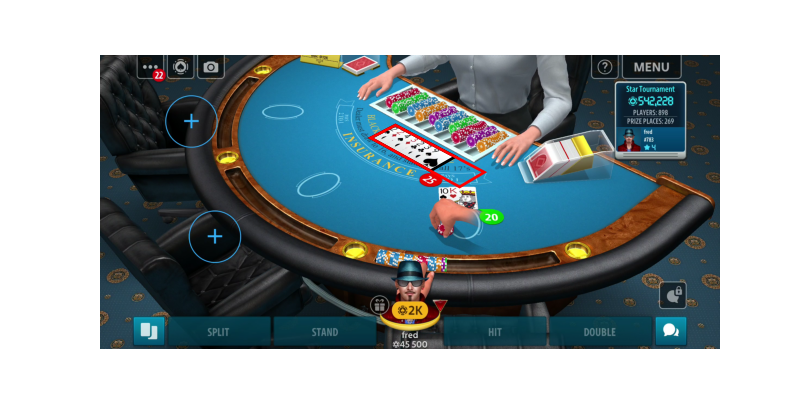

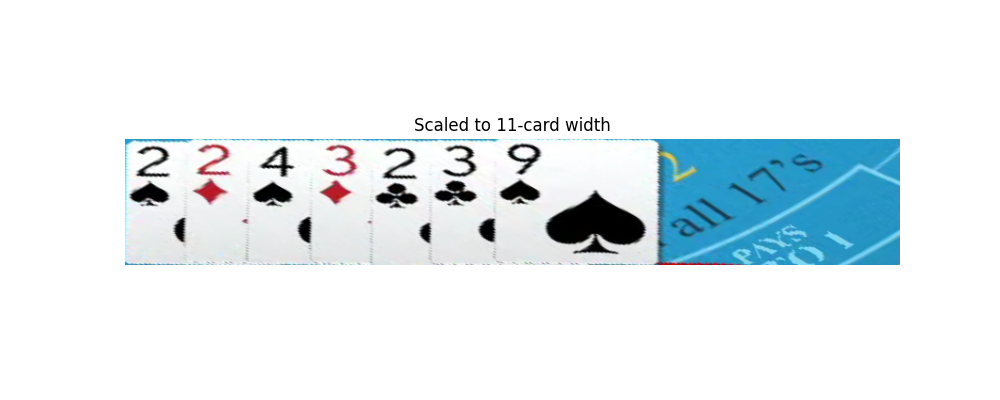

In [12]:
# Visualize scaled polygon and extract for 11 cards
f, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.imshow(img_np)
ax.set_axis_off()
ax.add_patch(Polygon(poly_pts, closed=True, fill=False, ec="black", lw=2))
ax.add_patch(Polygon(poly_pts_11, closed=True, fill=False, ec="red", lw=2))

cards_11 = image_utils.wrap_perspective(
    img_np, poly_pts_11, card_width + card_peek_width * 10, card_height
)

f2, ax2 = plt.subplots(1, 1, figsize=(10, 4))
ax2.imshow(cards_11)
ax2.set_title("Scaled to 11-card width")
ax2.set_axis_off()

get_cards(cards_11)

In [13]:
get_cards(cards)

(['2s', '2d', '4s', '3d', '2c', '3c', '9s'],)

In [14]:
import ocr_cards

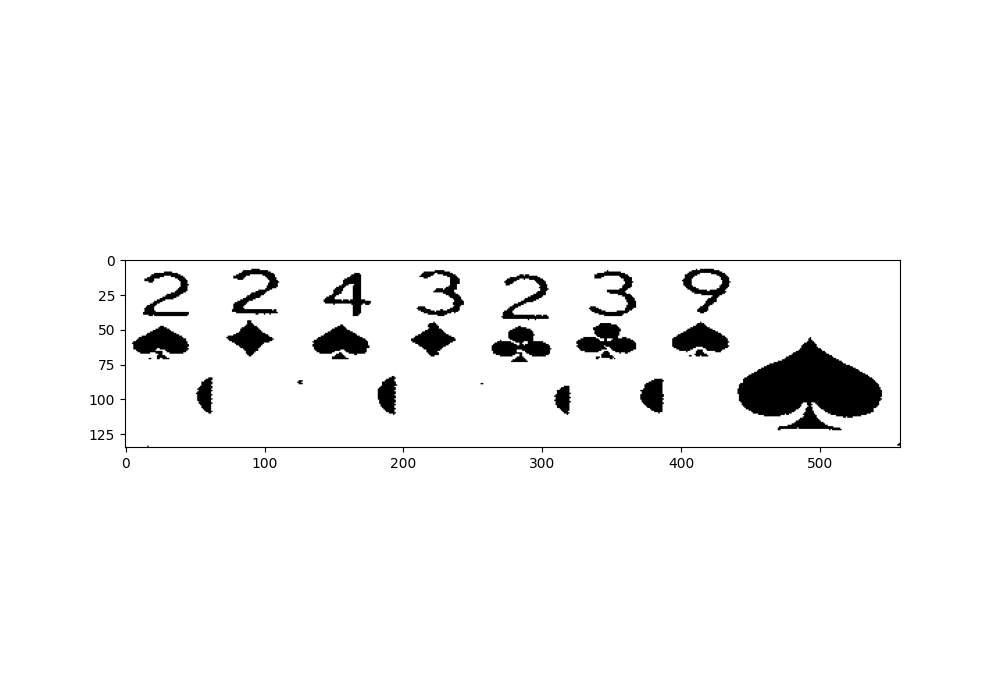

In [15]:
f, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.imshow(ocr_cards.to_bnw(cards), cmap="gray")

In [16]:
get_cards(cards_11)

(['2s', '2d', '4s', '3d', '2c', '3c', '9s'],)

In [17]:
import get_cards_playing


matches = image_utils.find_subimages(cards_11, get_cards_playing._suit_templates, threshold=0.9)
digit_images = get_cards_playing.extract_card_values_img(cards, matches)

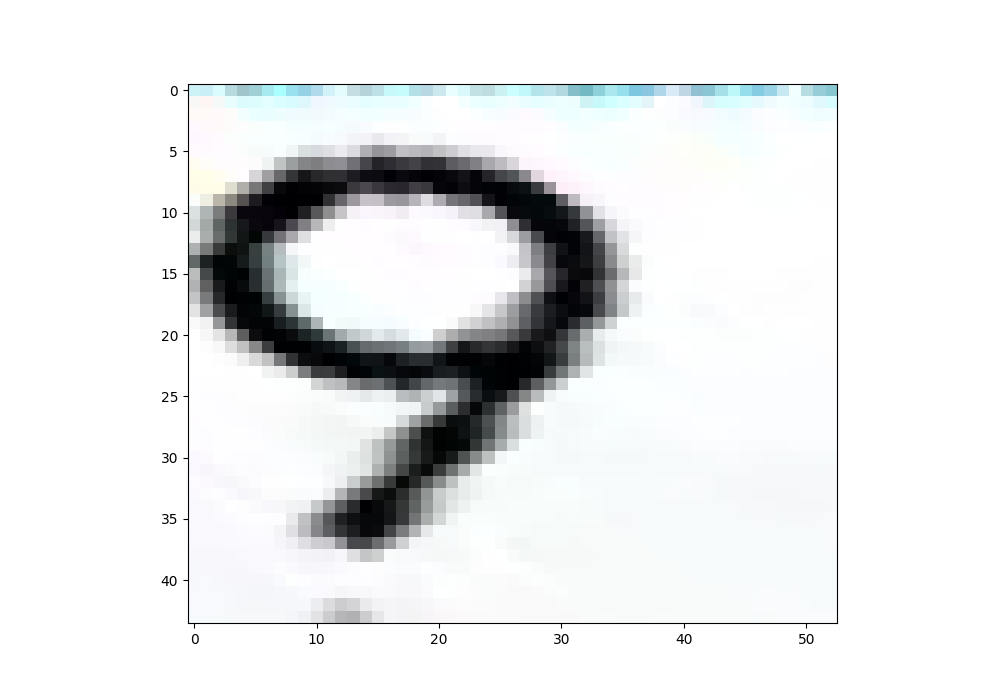

In [24]:
f, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.imshow(digit_images[0][0])